# Balabit testing first-movement pattern: user7

This notebook reads the first movement from every testing session for this user.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

USER_ID = "user7"
CAPTURE_DIR_NAME = "balabit_test_files_first_movements"
PROJECT_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "outputs").is_dir()
)
USER_DIR = PROJECT_ROOT / "outputs" / CAPTURE_DIR_NAME / USER_ID

session_rows = []
for json_path in sorted(USER_DIR.glob("session_*.json")):
    with json_path.open() as handle:
        capture = json.load(handle)
    for point_index, point in enumerate(capture.get("points", [])):
        session_rows.append({
            "session_id": json_path.stem,
            "point_index": point_index,
            "timestamp_ms": point["timestamp_ms"],
            "x": point["x"],
            "y": point["y"],
            "event_type": point["event_type"],
            "button": point["button"],
        })

points = pd.DataFrame(session_rows)
if points.empty:
    raise ValueError(f"No first movements found for {USER_ID} in {USER_DIR}")
print(f"User: {USER_ID}")
print(f"Sessions: {points['session_id'].nunique()}")
print(f"First-movement points: {len(points):,}")
points


User: user7
Sessions: 151
First-movement points: 151


,session_id,point_index,timestamp_ms,x,y,event_type,button
0,session_0061629194,0,0.0,613.0,140.0,Move,NoButton
1,session_0147719489,0,0.0,351.0,384.0,Move,NoButton
2,session_0244684556,0,0.0,482.0,551.0,Move,NoButton
3,session_0245934723,0,0.0,268.0,54.0,Move,NoButton
4,session_0390975032,0,0.0,418.0,591.0,Move,NoButton
...,...,...,...,...,...,...,...
146,session_9739246177,0,0.0,1199.0,347.0,Move,NoButton
147,session_9792054965,0,0.0,219.0,430.0,Move,NoButton
148,session_9877506321,0,0.0,133.0,847.0,Move,NoButton
149,session_9880892041,0,0.0,254.0,238.0,Move,NoButton


/tmp/ipykernel_14471/1855233638.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


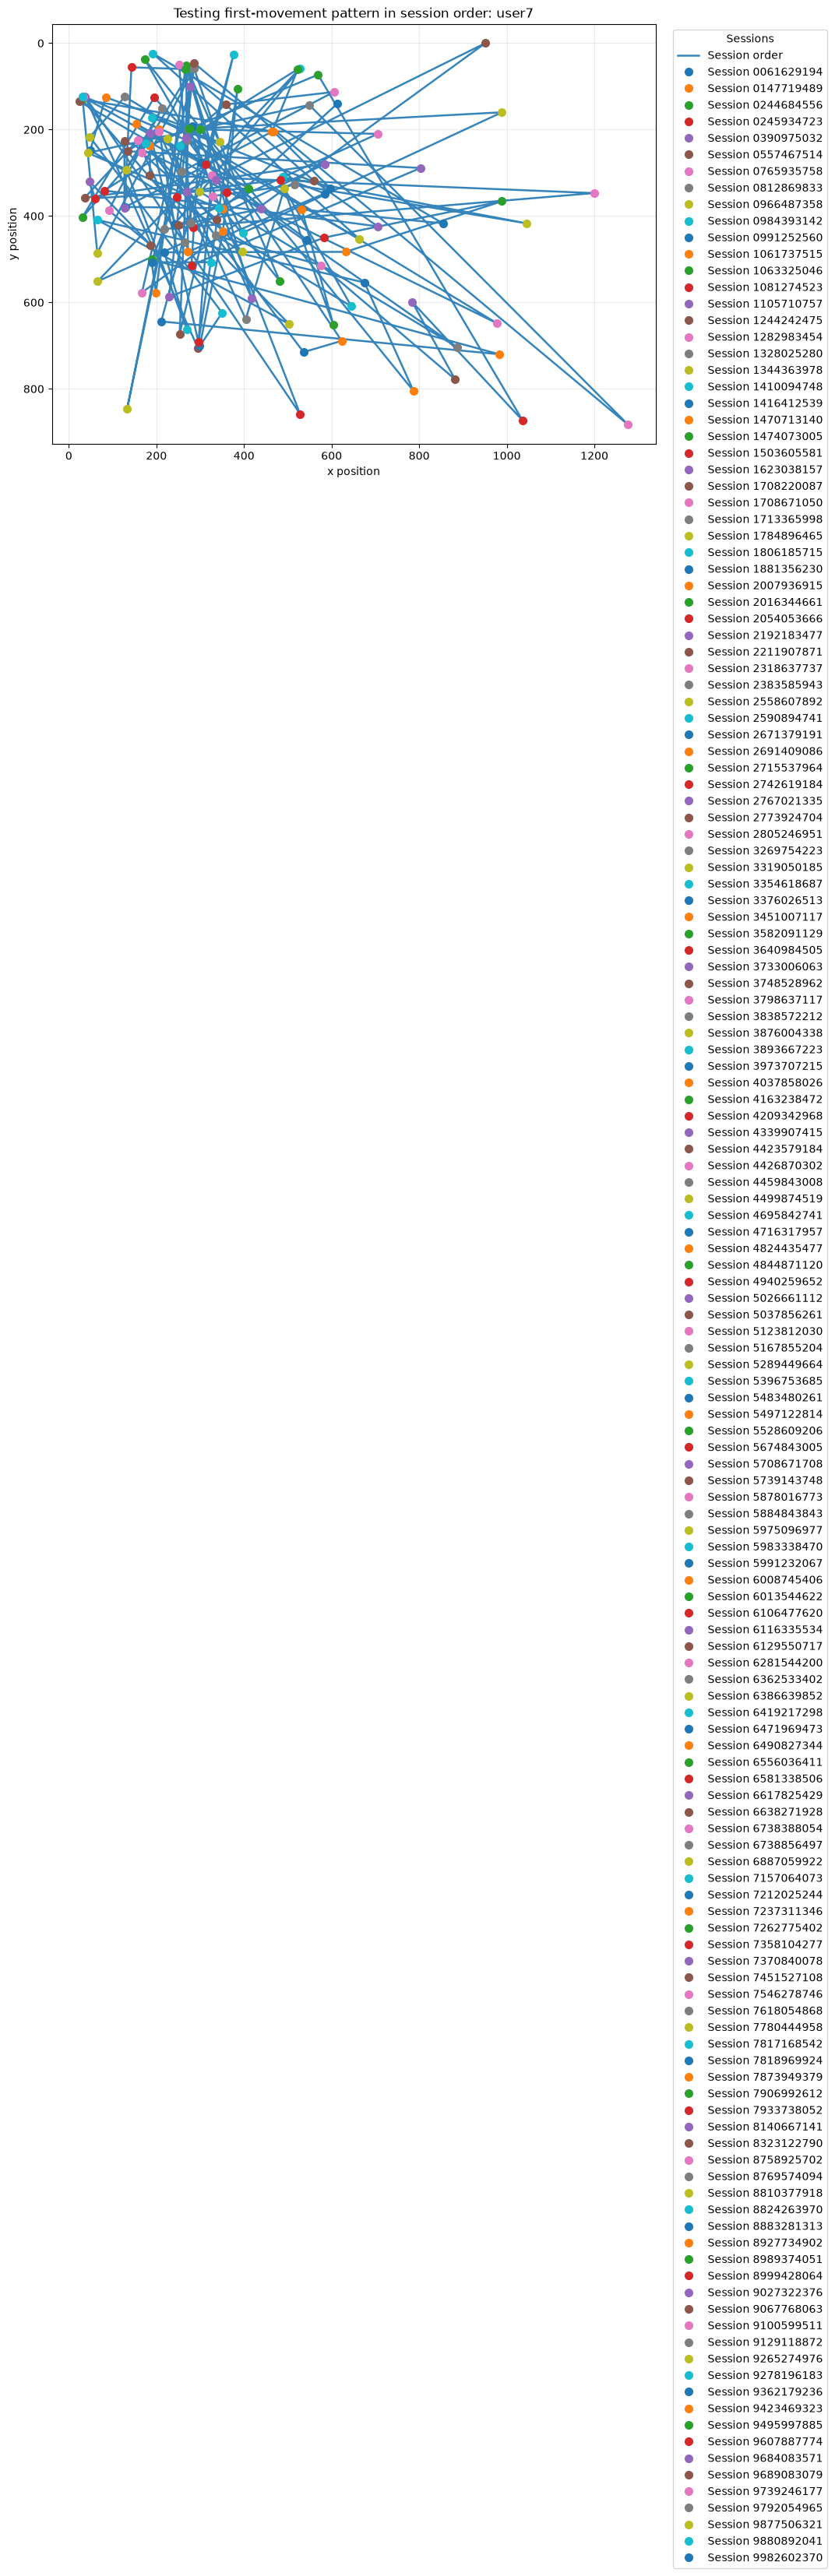

In [2]:
ordered_points = points.sort_values(
    "session_id",
    key=lambda values: values.str.replace("session_", "", regex=False).astype(int),
)

x_values = ordered_points["x"].tolist()
y_values = ordered_points["y"].tolist()
session_labels = ordered_points["session_id"].str.replace("session_", "", regex=False).tolist()

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(x_values, y_values, linewidth=1.8, color="tab:blue", alpha=0.9, label="Session order")
for x_value, y_value, session_label in zip(x_values, y_values, session_labels):
    ax.plot(x_value, y_value, marker="o", linestyle="None", markersize=7, label=f"Session {session_label}")

ax.set_title(f"Testing first-movement pattern in session order: {USER_ID}")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.invert_yaxis()
ax.grid(alpha=0.25)
ax.legend(title="Sessions", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()